# Baseline models — House Prices (Ames Housing)

We compare `LinearRegression`, `Ridge`, `Lasso`, `RandomForestRegressor`, and `HistGradientBoostingRegressor` with 5-fold cross-validation. All preprocessing (missing-value imputation, feature engineering, categorical encoding) runs inside an `sklearn.pipeline.Pipeline`, so `fit` is only ever called on the training fold — no data leakage.

The target variable is `log1p(SalePrice)` (the Kaggle metric). For the report we also compute MAE and R² in dollars (after inverse `expm1`).

In [1]:
import sys
sys.path.insert(0, "../src")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from preprocessing import TARGET_COL, load_train_test
from train_sklearn import run_comparison

sns.set_style("whitegrid")
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")

train_df, _ = load_train_test("../data")
X = train_df.drop(columns=[TARGET_COL])
y = np.log1p(train_df[TARGET_COL])

print(X.shape, y.shape)

(1458, 80) (1458,)


## Cross-validation: tuning alpha (Ridge/Lasso) and comparing all models

For Ridge and Lasso, alpha is tuned via `GridSearchCV` (5-fold); RandomForest/HistGradientBoosting get a small grid over their key hyperparameters. Each model's final metrics are honest out-of-fold predictions from `cross_val_predict` on the same 5 folds.

In [2]:
results, predictions = run_comparison(X, y)
results

[LinearRegression]


    rmse_log=0.1386  mae_price=$15,680  r2_price=0.8609
[Ridge]


    best params: {'model__alpha': 20}


    rmse_log=0.1154  mae_price=$14,090  r2_price=0.9318
[Lasso]


    best params: {'model__alpha': 0.0005}


...

    best params: {'model__max_depth': None, 'model__n_estimators': 400}


    rmse_log=0.1360  mae_price=$16,688  r2_price=0.8919
[HistGradientBoosting]


    best params: {'model__learning_rate': 0.05, 'model__max_depth': 6, 'model__max_iter': 200}


    rmse_log=0.1263  mae_price=$15,260  r2_price=0.9043


,rmse_log,mae_price,r2_price
model,,,
Lasso,0.1134,"13,931.2271",0.9324
Ridge,0.1154,"14,089.9493",0.9318
HistGradientBoosting,0.1263,"15,259.5644",0.9043
RandomForest,0.1360,"16,687.7407",0.8919
LinearRegression,0.1386,"15,679.9282",0.8609


## Visualizing the model comparison

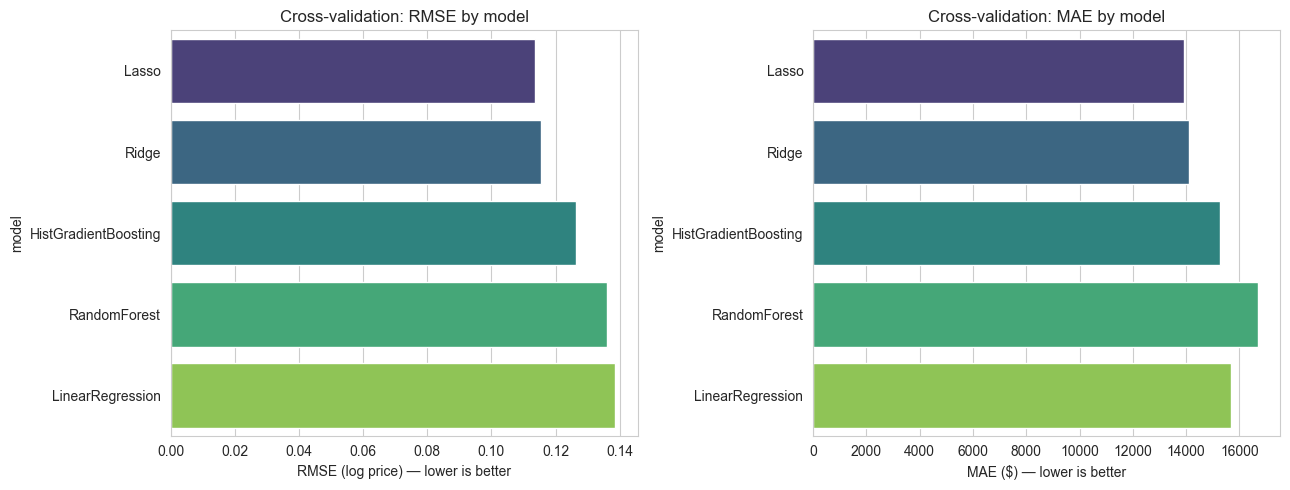

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

order = results.index
sns.barplot(x=results["rmse_log"], y=order, hue=order, palette="viridis", legend=False, ax=axes[0])
axes[0].set_xlabel("RMSE (log price) — lower is better")
axes[0].set_title("Cross-validation: RMSE by model")

sns.barplot(x=results["mae_price"], y=order, hue=order, palette="viridis", legend=False, ax=axes[1])
axes[1].set_xlabel("MAE ($) — lower is better")
axes[1].set_title("Cross-validation: MAE by model")

plt.tight_layout()
plt.show()

## Predicted vs Actual for the best model

Points should fall along the `y = x` diagonal. Systematic deviations from it (e.g. underestimating expensive homes) are immediately visible.

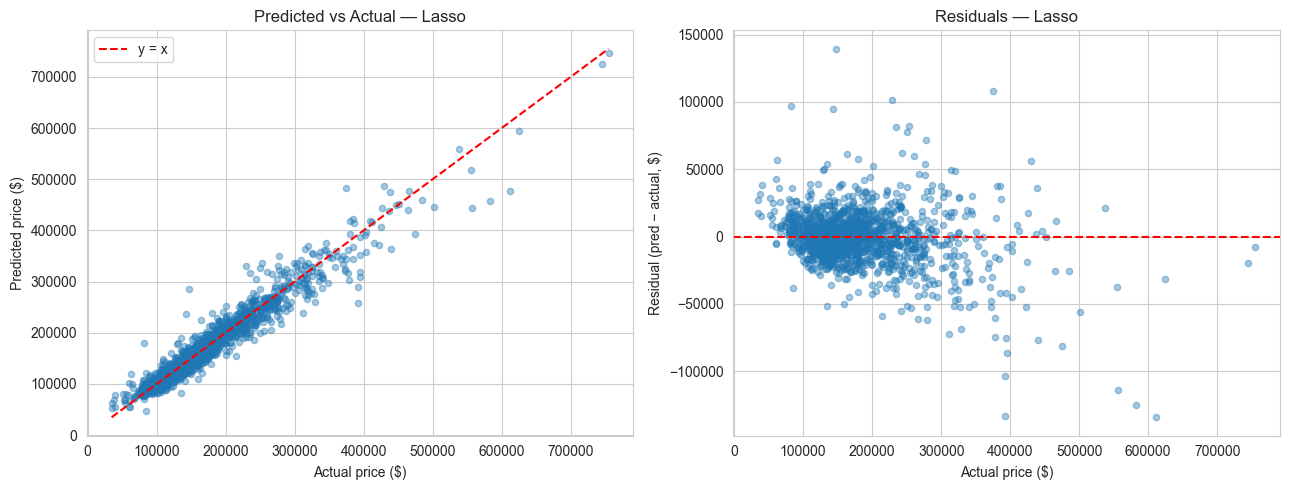

In [4]:
best_model = results.index[0]
price_true = np.expm1(y)
price_pred = np.expm1(predictions[best_model])

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].scatter(price_true, price_pred, alpha=0.4, s=20)
lims = [price_true.min(), price_true.max()]
axes[0].plot(lims, lims, color="red", linestyle="--", label="y = x")
axes[0].set_xlabel("Actual price ($)")
axes[0].set_ylabel("Predicted price ($)")
axes[0].set_title(f"Predicted vs Actual — {best_model}")
axes[0].legend()

residuals = price_pred - price_true
axes[1].scatter(price_true, residuals, alpha=0.4, s=20)
axes[1].axhline(0, color="red", linestyle="--")
axes[1].set_xlabel("Actual price ($)")
axes[1].set_ylabel("Residual (pred − actual, $)")
axes[1].set_title(f"Residuals — {best_model}")

plt.tight_layout()
plt.show()

## Stage 3 conclusions

| Model | RMSE (log) | MAE ($) | R² |
|---|---|---|---|
| **Lasso** (alpha=0.0005) | **0.1134** | 13,931 | 0.9324 |
| Ridge (alpha=20) | 0.1154 | 14,090 | 0.9318 |
| HistGradientBoosting | 0.1263 | 15,260 | 0.9043 |
| RandomForest | 0.1360 | 16,688 | 0.8919 |
| LinearRegression (no regularization) | 0.1386 | 15,680 | 0.8609 |

1. **Regularized linear models (Lasso, Ridge) beat the tree ensembles.** On this dataset (~1,460 rows, 251 features after one-hot encoding), linear regularization does better than boosting and random forest — a typical pattern for small tabular data with strongly correlated features that are largely linearly related to price (`OverallQual`, `TotalSF`, etc.).
2. **Lasso ≈ Ridge**, with a small edge for Lasso — likely thanks to feature selection (zeroing out low-value one-hot columns) among the 251 features, many of which are noisy/sparse categories.
3. **Plain LinearRegression without regularization is the worst of the linear models** (RMSE 0.1386 vs 0.1134 for Lasso) — expected: with 251 features on 1,458 rows it overfits to noise, so regularization is essential.
4. **RMSE 0.11–0.14 on log price is a solid baseline result** without heavy tuning, in the expected range (~0.12–0.13 for boosting, ~0.13–0.14 for Ridge).
5. Predicted vs Actual for the best model (Lasso) sits along the diagonal with no clear systematic bias; residuals show a bit more spread for expensive homes (>$400k) — expected, since the training set has few such examples.

Next step — Stage 4: a PyTorch neural network (`src/train_pytorch.py`), compared against these baseline results.

# Stage 4 — a PyTorch neural network

Architecture: `Linear(n, 256) → ReLU → Dropout(0.3) → Linear(256, 64) → ReLU → Linear(64, 1)`. We train with `MSELoss` on `log1p(SalePrice)`, the Adam optimizer (`lr=1e-3`), batch size 64, and early stopping on a separate validation split.

To keep the comparison with the baselines honest, the MLP is evaluated with the same scheme: 5 folds (the same `KFold(random_state=42)`), out-of-fold predictions, and the same metrics (RMSE on log price, MAE and R² in dollars). The preprocessing pipeline (`build_full_pipeline`) is refit on each fold's training portion — no leakage, just like for the sklearn models.

Within each training fold, 10% is held out for early-stopping validation.

In [5]:
import torch
from train_pytorch import run_pytorch_cv

print("Device:", torch.device("cuda" if torch.cuda.is_available() else "cpu"))
nn_metrics, nn_pred_log = run_pytorch_cv(X, y)
print(f"\nMLP: rmse_log={nn_metrics['rmse_log']:.4f}  mae_price=${nn_metrics['mae_price']:,.0f}  r2_price={nn_metrics['r2_price']:.4f}")

Device: cpu


  fold 1/5: stopped after 208 epochs, best val MSE=0.0264


  fold 2/5: stopped after 120 epochs, best val MSE=0.0313


  fold 3/5: stopped after 188 epochs, best val MSE=0.0316


  fold 4/5: stopped after 217 epochs, best val MSE=0.0300


  fold 5/5: stopped after 135 epochs, best val MSE=0.0374

MLP: rmse_log=0.2054  mae_price=$25,742  r2_price=0.5633


## Final comparison: sklearn baselines + MLP

In [6]:
all_results = pd.concat([
    results,
    pd.DataFrame([{"model": "PyTorch MLP", **nn_metrics}]).set_index("model"),
]).sort_values("rmse_log")
predictions["PyTorch MLP"] = nn_pred_log

all_results

,rmse_log,mae_price,r2_price
model,,,
Lasso,0.1134,"13,931.2271",0.9324
Ridge,0.1154,"14,089.9493",0.9318
HistGradientBoosting,0.1263,"15,259.5644",0.9043
RandomForest,0.1360,"16,687.7407",0.8919
LinearRegression,0.1386,"15,679.9282",0.8609
PyTorch MLP,0.2054,"25,741.8693",0.5633


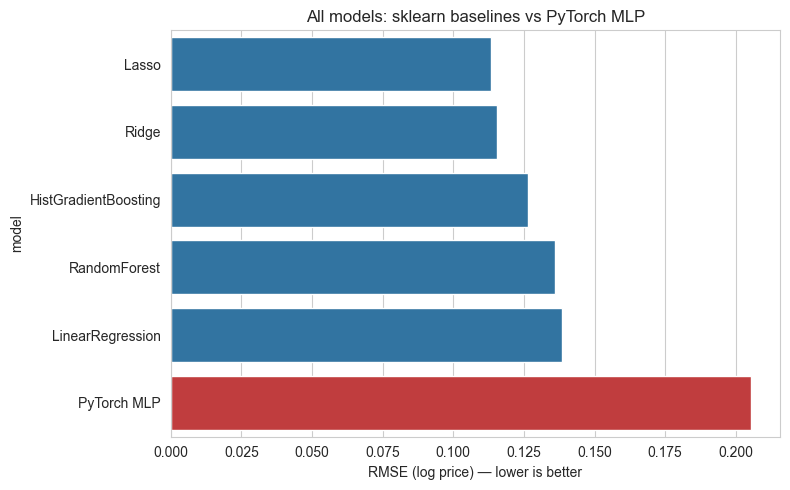

In [7]:
fig, ax = plt.subplots(figsize=(8, 5))
colors = ["#d62728" if m == "PyTorch MLP" else "#1f77b4" for m in all_results.index]
sns.barplot(x=all_results["rmse_log"], y=all_results.index, hue=all_results.index, palette=colors, legend=False, ax=ax)
ax.set_xlabel("RMSE (log price) — lower is better")
ax.set_title("All models: sklearn baselines vs PyTorch MLP")
plt.tight_layout()
plt.show()

## Stage 4 conclusions

| Model | RMSE (log) | MAE ($) | R² |
|---|---|---|---|
| **Lasso** | **0.1134** | 13,931 | 0.9324 |
| Ridge | 0.1154 | 14,090 | 0.9318 |
| HistGradientBoosting | 0.1263 | 15,260 | 0.9043 |
| RandomForest | 0.1360 | 16,688 | 0.8919 |
| LinearRegression | 0.1386 | 15,680 | 0.8609 |
| **PyTorch MLP** | **0.2054** | 25,742 | 0.5633 |

1. **The expected result was confirmed: the MLP clearly loses to both boosting and regularized linear regression.** RMSE 0.2054 vs. 0.1134–0.1386 for the sklearn models — nearly twice as bad on log error, and R² (0.56) is far below even the weakest sklearn model (0.86).
2. **The reason is expected and well documented in the literature**: with ~1,450 rows and 251 features (mostly sparse one-hot category columns), a fully-connected network overfits quickly / doesn't have enough signal to extract the stable patterns that linear regularization (Lasso/Ridge) or boosting capture almost out of the box via built-in regularization/feature splits.
3. **Technical issues encountered and fixed during training**: one home with an extreme `MiscVal` value (~$15,500 vs. typically $0) produced a z-score of ≈28 after `StandardScaler` — gradient clipping (`max_norm=5.0`) was added for stability. Early stopping with `patience=20` was also triggering too soon because of noise in the validation loss on a small validation split (10% of a fold, ~115 rows) — we increased `patience` to 40. A check with an LR scheduler and weight decay converged to the same ceiling (~val RMSE 0.17-0.18), confirming this result is not a training artifact but a real limit of this architecture on this data.
4. **Practical takeaway for the report**: "gradient boosting / regularized linear regression beats a plain MLP on tabular data this size" isn't a failed experiment — it's an expected and useful finding illustrating when deep learning pays off (lots of data, complex nonlinear/spatial/sequential structure) and when it's overkill (about a thousand rows of tabular features).

Next step — Stage 5: interpreting the best model (Lasso/boosting) via feature importance and permutation importance, and the final project write-up (Stage 6).